In [24]:
import numpy as np
import matplotlib.pyplot as plt
-
import sys
import os
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Transformer



In [2]:
# import storm dataset
from pathlib import Path


# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))



# Import storm dataset and related modules
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_direction import mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length, mean_velocity, mean_direction, mean_direction_ln, mean_direction_weighted
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, plot_storm_track, plot_storm_time_steps

In [4]:
# Set the SST catalog folder path
folder = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Results/Domain_58.0_circle_10000km2/StormCatalog'
event_list = os.listdir(folder)
event_list = [event for event in event_list if event.endswith('.nc')]

In [5]:
##Run of storm tracking for specif event
n_storm = '_92_' # storm number
name = [s for s in event_list if str(n_storm) in s][0] # find the storm name
#name = 'IOWA_Domain.nc_storm_27_20210324.nc'
event_dict = {}
ds = xr.open_dataset(os.path.join(folder, name))
print(name)
storm_tracking_event(ds, event_dict, morph_radius=4, high_threshold=1)
continuos_storm(event_dict)
storm_tracking_features(event_dict, ellipse_fit='momentum')

IOWA_Domain.nc_storm_92_20070924.nc
The longest storm has a valid duration of 14 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2007-09-24T22:00:00.000000000 to 2007-09-25T11:00:00.000000000
Selected storm duration 14 hours


{'storm_pcrp': <xarray.Variable (time: 24, latitude: 150, longitude: 150)> Size: 2MB
 array([[[0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.],
         ...,
         [0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.]],
 
        [[0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.],
         ...,
         [0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.]],
 
        ...,
 
        [[0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.],
         ...,
         [0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.]],
 
        [[0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.],
         ...,
         [0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.]]], shape=(24, 150, 150), dtype=float32)
 Attributes:
     units:      mm hr^-1
     long_name:  precipitation rate,
 'identification_array': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [

In [6]:
def fit_ellipse_to_rainfall(rainfall_field, x_coords, y_coords, threshold=1.0):
    """
    Fits an ellipse to a 2D rainfall field using the method of moments.

    Args:
        rainfall_field (np.ndarray): A 2D NumPy array where each value is the
                                    rainfall intensity.
        threshold (float): The minimum rainfall intensity to consider.
                           Values below this will be set to zero.

    Returns:
        dict: A dictionary containing the ellipse parameters:
              'center' (tuple), 'major_axis' (float), 'minor_axis' (float),
              'angle_deg' (float). Returns None if no data is above the threshold.
    """
    # Ensure input is a numpy array
    field = np.array(rainfall_field)
    
    # Apply threshold
    field_thresholded = np.where(field >= threshold, field, 0)

    

    # Calculate zeroth moment (total intensity)
    m00 = np.sum(field_thresholded)

    # Check if there is any rainfall above the threshold
    if m00 == 0:
        return None

    # First moments (to find the centroid)
    m10 = np.sum(x_coords * field_thresholded)
    m01 = np.sum(y_coords * field_thresholded)

    # --- Step 2: Calculate Ellipse Center (Centroid) ---
    x_bar = m10 / m00
    y_bar = m01 / m00

    # Second central moments (to find size and orientation)
    mu20 = np.sum((x_coords - x_bar)**2 * field) / m00
    mu02 = np.sum((y_coords - y_bar)**2 * field) / m00
    mu11 = np.sum((x_coords - x_bar) * (y_coords - y_bar) * field) / m00

    # --- Step 3: Calculate Ellipse Axes and Angle ---
    # Common term
    common_term = np.sqrt((mu20 - mu02)**2 + 4 * mu11**2)

    # Major and minor axes (proportional to standard deviations)
    # The factor 2*sqrt(2) scales the ellipse to contain ~86.5% of the total intensity
    # under a Gaussian assumption, a common convention.
    major_axis = 2 * np.sqrt(2) * np.sqrt(0.5 * ((mu20 + mu02) + common_term))
    minor_axis = 2 * np.sqrt(2) * np.sqrt(0.5 * ((mu20 + mu02) - common_term))

    # Orientation angle
    angle_rad = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
    angle_deg = np.degrees(angle_rad)

    return {
        'center': (x_bar, y_bar),
        'major_axis': major_axis,
        'minor_axis': minor_axis,
        'angle_deg': angle_deg
    }

In [7]:
event_dict['selected_storm_time_steps']

<xarray.DataArray 'time' (time: 14)> Size: 112B
array(['2007-09-24T22:00:00.000000000', '2007-09-24T23:00:00.000000000',
       '2007-09-25T00:00:00.000000000', '2007-09-25T01:00:00.000000000',
       '2007-09-25T02:00:00.000000000', '2007-09-25T03:00:00.000000000',
       '2007-09-25T04:00:00.000000000', '2007-09-25T05:00:00.000000000',
       '2007-09-25T06:00:00.000000000', '2007-09-25T07:00:00.000000000',
       '2007-09-25T08:00:00.000000000', '2007-09-25T09:00:00.000000000',
       '2007-09-25T10:00:00.000000000', '2007-09-25T11:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 112B 2007-09-24T22:00:00 ... 2007-09-25T11...

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


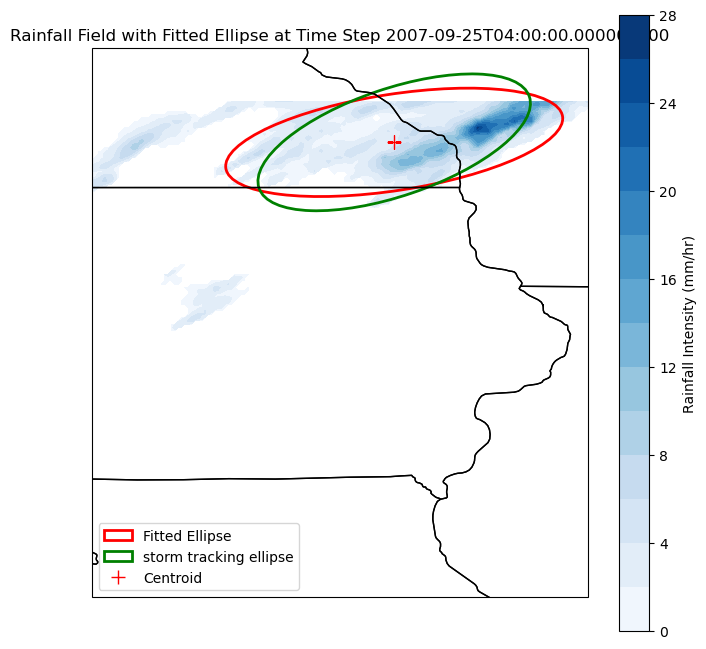

In [47]:
time_step = 6
rainfall_data = event_dict['selected_storm'][time_step]
x_coords, y_coords = event_dict['lon_array'], event_dict['lat_array']
precipitation_threshold = np.quantile(rainfall_data[rainfall_data!=0].flatten(), q = 0.5)
ellipse_params = fit_ellipse_to_rainfall(rainfall_data, x_coords, y_coords,  threshold=1)
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
nx, ny = x_coords, y_coords

# Plot the rainfall field
masked_data = np.where(rainfall_data < 0.1,np.nan, rainfall_data)
c = ax.contourf(x_coords, y_coords, masked_data, cmap='Blues', levels=15)
fig.colorbar(c, ax=ax, label='Rainfall Intensity (mm/hr)')

# Create the ellipse patch
ellipse = Ellipse(
    xy=ellipse_params['center'],
    width=ellipse_params['major_axis'],
    height=ellipse_params['minor_axis'],
    angle=ellipse_params['angle_deg'],
    edgecolor='r',
    facecolor='none',
    linewidth=2,
    label='Fitted Ellipse'
)
sr = event_dict['storm_record']


ax.add_patch(ellipse)
ellipse2 = Ellipse(
    xy=(event_dict['storm_lon_cent'][time_step], event_dict['storm_lat_cent'][time_step]),
    width=sr['major_axis_length(m)'][time_step]/111000,
    height=sr['minor_axis_length(m)'][time_step]/111000,
    angle=sr['ellipse_angle (degree)'][time_step],
    edgecolor='g',
    facecolor='none',
    linewidth=2,
    label='storm tracking ellipse'
)
ax.add_patch(ellipse2)
ax.add_feature(cfeature.STATES, edgecolor='black')


# Plot the centroid
ax.plot(ellipse_params['center'][0], ellipse_params['center'][1], 'r+', markersize=10, label='Centroid')

ax.set_title('Rainfall Field with Fitted Ellipse at Time Step {}'.format(event_dict['selected_storm_time_steps'][time_step].values))
ax.set_xlabel('X Coordinate (pixels)')
ax.set_ylabel('Y Coordinate (pixels)')
ax.set_aspect('equal', 'box')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [14]:
ellipse_params['angle_deg']

np.float64(33.1491559574681)

In [13]:
sr = event_dict['storm_record']
sr['ellipse_angle (degree)']


0     76.094144
1     76.094144
2     54.849948
3     48.687676
4     47.106167
5     43.438132
6     18.712325
7     28.537420
8     30.176366
9     33.030715
10    46.286751
11    42.796131
12    59.038083
13    43.337078
Name: ellipse_angle (degree), dtype: float64

# fitting on projected coordinates

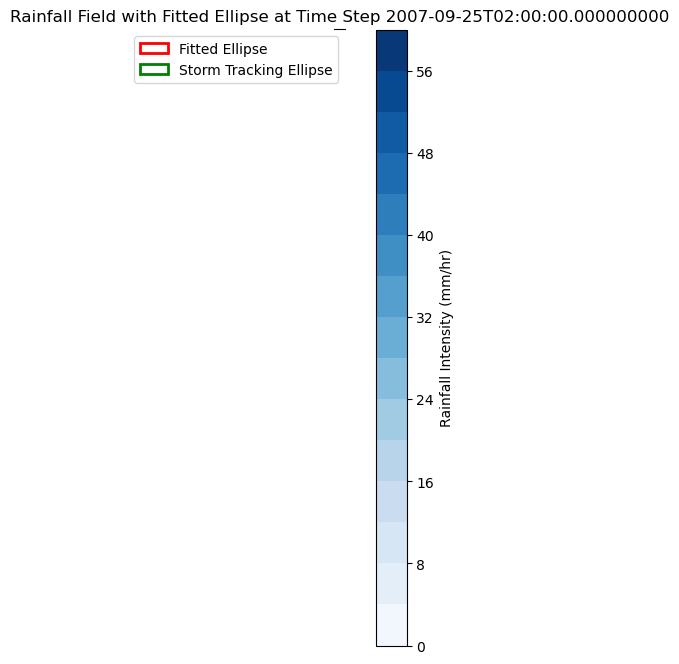

In [45]:
time_step = 4
rainfall_data = event_dict['selected_storm'][time_step]
x_coords, y_coords = event_dict['lon_prj_array'], event_dict['lat_prj_array']
precipitation_threshold = np.quantile(rainfall_data[rainfall_data!=0].flatten(), q = 0.5)
ellipse_params = fit_ellipse_to_rainfall(rainfall_data, x_coords, y_coords,  threshold=1)
# Create the plot
#fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
nx, ny = x_coords, y_coords
transformer = Transformer.from_crs("EPSG:2163", "EPSG:4326", always_xy=True)
lon_ellipse, lat_ellipse = transformer.transform(ellipse_params['center'][0], ellipse_params['center'][1])
# Plot the rainfall field
masked_data = np.where(rainfall_data < 0.1, np.nan, rainfall_data)
c = ax.contourf(x_coords, y_coords, masked_data, cmap='Blues', levels=15, transform=ccrs.PlateCarree())
fig.colorbar(c, ax=ax, label='Rainfall Intensity (mm/hr)')

# Create the ellipse patch
ellipse = Ellipse(
    xy=(lon_ellipse, lat_ellipse),
    width=ellipse_params['major_axis']/111000,
    height=ellipse_params['minor_axis']/111000,
    angle=ellipse_params['angle_deg'],
    edgecolor='r',
    facecolor='none',
    linewidth=2,
    label='Fitted Ellipse'
)
sr = event_dict['storm_record']


# Add the first ellipse
ellipse.set_transform(ax.transData)  # Use ax.transData for proper transformation
ax.add_patch(ellipse)

# Add the second ellipse
ellipse2 = Ellipse(
    xy=(event_dict['storm_lon_cent'][time_step], event_dict['storm_lat_cent'][time_step]),
    width=sr['major_axis_length(m)'][time_step]/111000,
    height=sr['minor_axis_length(m)'][time_step]/111000,
    angle=sr['ellipse_angle (degree)'][time_step],
    edgecolor='g',
    facecolor='none',
    linewidth=2,
    label='Storm Tracking Ellipse'
)
ellipse2.set_transform(ax.transData)  # Use ax.transData for proper transformation
ax.add_patch(ellipse2)
ax.add_feature(cfeature.STATES, edgecolor='black')


# Plot the centroid
#ax.plot(ellipse_params['center'][0], ellipse_params['center'][1], 'r+', markersize=10, label='Centroid')

ax.set_title('Rainfall Field with Fitted Ellipse at Time Step {}'.format(event_dict['selected_storm_time_steps'][time_step].values))
ax.set_xlabel('X Coordinate (pixels)')
ax.set_ylabel('Y Coordinate (pixels)')
ax.set_aspect('equal', 'box')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [30]:
lon_ellipse, lat_ellipse

(-92.63123000333907, 43.73498246247366)

In [52]:
sr['ellipse_angle (degree)']

0     76.094144
1     76.094144
2     54.849948
3     48.687676
4     47.106167
5     43.438132
6     18.712325
7     28.537420
8     30.176366
9     33.030715
10    46.286751
11    42.796131
12    59.038083
13    43.337078
Name: ellipse_angle (degree), dtype: float64

In [51]:
ellipse_params['angle_deg']

np.float64(8.765835991568725)

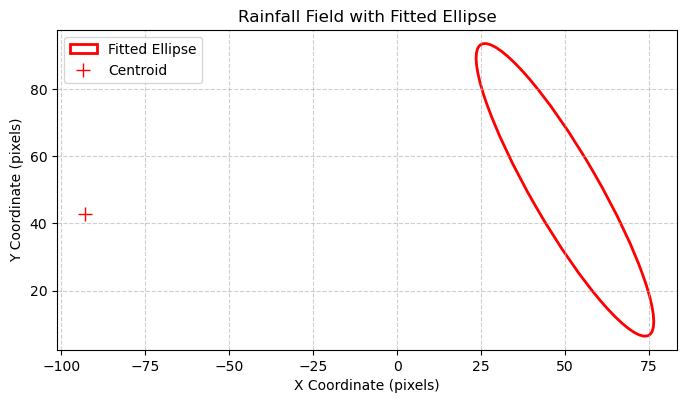

In [29]:
# Create the ellipse patch
ellipse = Ellipse(
    xy=(50, 50),
    width=100,
    height=20,
    angle=120,
    edgecolor='r',
    facecolor='none',
    linewidth=2,
    label='Fitted Ellipse'
)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.add_patch(ellipse)

# Plot the centroid
ax.plot(ellipse_params['center'][0], ellipse_params['center'][1], 'r+', markersize=10, label='Centroid')

ax.set_title('Rainfall Field with Fitted Ellipse')
ax.set_xlabel('X Coordinate (pixels)')
ax.set_ylabel('Y Coordinate (pixels)')
ax.set_aspect('equal', 'box')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

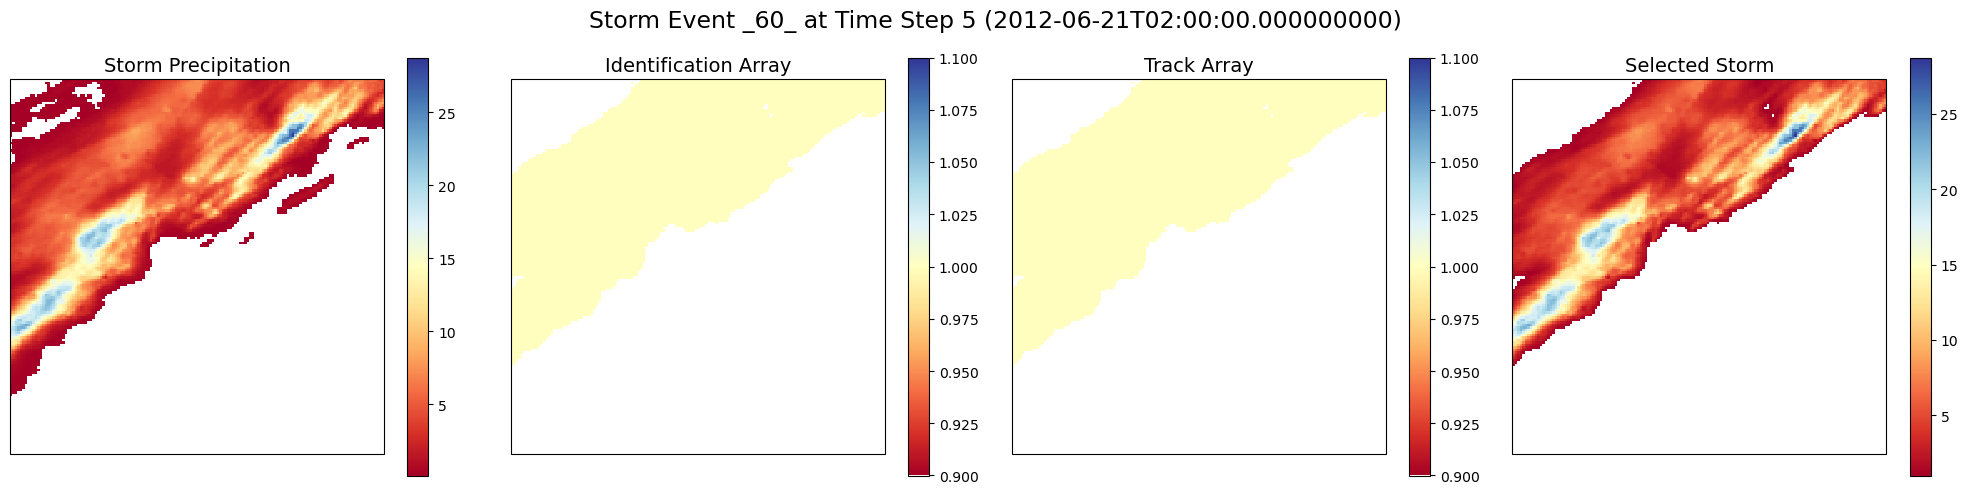

In [28]:
def plot_event_arrays(event_dict, time_step):
    """
    Plots the arrays in the event_dict at a given time step, masking 0 values.

    Parameters:
    - event_dict (dict): Dictionary containing arrays to plot.
    - time_step (int): Time step to plot.

    Arrays to plot:
    - storm_prcp
    - identification_array
    - track_array
    - selected_storm
    """
    arrays_to_plot = ['storm_pcrp', 'identification_array', 'track_array', 'selected_storm']
    titles = ['Storm Precipitation', 'Identification Array', 'Track Array', 'Selected Storm']

    a = event_dict['selected_storm_time_steps']
    b = event_dict['storm_time']
    matching_indices = np.where(np.isin(b.values, a.values))[0]
    storm_index = matching_indices[time_step]
    
    
    fig, axes = plt.subplots(1, len(arrays_to_plot), figsize=(20, 5), subplot_kw={'projection': ccrs.PlateCarree()})
    for i, array_name in enumerate(arrays_to_plot):
        if array_name == 'selected_storm':
            array = event_dict[array_name][time_step]
        else:
            array = event_dict[array_name][storm_index]
        masked_array = np.ma.masked_where(array <0.1, array)  # Mask 0 values
    
        rain = axes[i].pcolormesh(event_dict['lon_array'], event_dict['lat_array'], 
                             masked_array,
                             cmap='RdYlBu')
        axes[i].set_title(titles[i], fontsize=14)
        plt.colorbar(rain, ax=axes[i])
    plt.suptitle(f'Storm Event {n_storm} at Time Step {time_step} ({a[time_step].values})', fontsize=17)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_event_arrays(event_dict, time_step=time_step)

In [53]:
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, plot_storm_track, plot_storm_time_steps

In [ ]:
plot_storm_time_steps